In [24]:
import os
import shutil
import random

# Set the path to the original dataset
original_data_folder = "C:\\Users\\User\\Downloads\\Emotion_D\\Image"

# Set the path for the train and test folders
train_folder = "C:\\Users\\User\\Downloads\\Emotion_D\\train"
test_folder = "C:\\Users\\User\\Downloads\\Emotion_D\\test"

# Create train and test folders if they don't exist
if not os.path.exists(train_folder):
    os.makedirs(train_folder)
if not os.path.exists(test_folder):
    os.makedirs(test_folder)

# Set the ratio for train and test data
train_ratio = 0.8
test_ratio = 1 - train_ratio

# Iterate over the original data folder
for root, dirs, files in os.walk(original_data_folder):
    for file in files:
        # Decide whether to put the file in train or test set
        if random.uniform(0, 1) < train_ratio:
            destination_folder = train_folder
        else:
            destination_folder = test_folder

        # Create the corresponding label folder in train or test set
        label_folder = os.path.join(destination_folder, os.path.basename(root))
        if not os.path.exists(label_folder):
            os.makedirs(label_folder)

        # Copy the file to the appropriate folder
        shutil.copy2(os.path.join(root, file), label_folder)

print("Data splitting completed successfully!")

PermissionError: [WinError 5] Access is denied: 'C:\\Users\\User'

In [3]:
# import libs
from keras.layers import  Input, Dense, Flatten
from keras.models import Model
from keras.applications.resnet50 import ResNet50
from keras.applications.resnet50 import preprocess_input
from keras.preprocessing import image
from keras.preprocessing.image import ImageDataGenerator, load_img
from keras.models import Sequential
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
import keras
print("Libs imported")

#We are using resNet50, expected input size is [224,224]
IMAGE_SIZE=[128, 128]

Libs imported


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
import skimage.io
import keras.backend as K
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Flatten, Dropout,BatchNormalization ,Activation
from tensorflow.keras.models import Model, Sequential
from keras.applications.nasnet import NASNetLarge
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam

In [5]:
train_datagen = ImageDataGenerator(rescale = 1./255,
                                   validation_split = 0.2,
                                  
        rotation_range=5,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        #zoom_range=0.2,
        horizontal_flip=True,
        vertical_flip=True,
        fill_mode='nearest')

valid_datagen = ImageDataGenerator(rescale = 1./255,
                                  validation_split = 0.2)

test_datagen  = ImageDataGenerator(rescale = 1./255
                                  )

In [6]:
valid_dataset = valid_datagen.flow_from_directory(directory = "E:\\Capstone\\Dataset\\Gray_Img\\train",
                                                  target_size = (48,48),
                                                  class_mode = 'categorical',
                                                  subset = 'validation',
                                                  batch_size = 64)

Found 3225 images belonging to 7 classes.


In [7]:
train_dataset  = train_datagen.flow_from_directory(directory = "E:\\Capstone\\Dataset\\Gray_Img\\train",
                                                   target_size = (48,48),
                                                   class_mode = 'categorical',
                                                   subset = 'training',
                                                   batch_size = 64)

Found 12900 images belonging to 7 classes.


In [8]:
test_dataset = test_datagen.flow_from_directory(directory = "E:\\Capstone\\Dataset\\Gray_Img\\test",
                                                  target_size = (48,48),
                                                  class_mode = 'categorical',
                                                  batch_size = 64)

Found 4032 images belonging to 7 classes.


(48, 48, 3)
(1, 48, 48, 3)


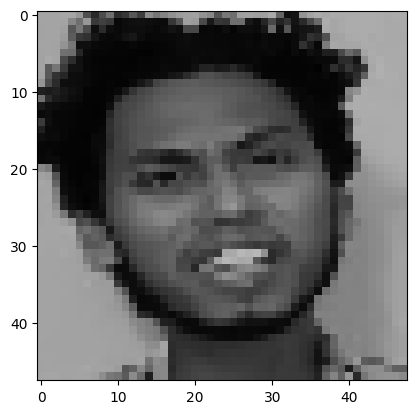

In [9]:
from keras.preprocessing import image
img = image.load_img("E:\\Capstone\\Dataset\\Gray_Img\\test\\G_Angry\\Angry_5_face.jpg",target_size=(48,48))
img = np.array(img)
plt.imshow(img)
print(img.shape)

img = np.expand_dims(img, axis=0)
from keras.models import load_model
print(img.shape)


In [32]:
base_model = tf.keras.applications.ResNet50(input_shape=(48,48,3),include_top=False,weights="imagenet")

In [33]:
# Freezing Layers

for layer in base_model.layers[:-4]:
    layer.trainable=False

In [34]:
# Building Model

model.add(Flatten())
model.add(Dense(32,kernel_initializer='he_uniform'))

model.add(Dense(7,activation='softmax'))

In [35]:
# Model Summary

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 2, 2, 2048)        23587712  
                                                                 
 dropout_3 (Dropout)         (None, 2, 2, 2048)        0         
                                                                 
 flatten_1 (Flatten)         (None, 8192)              0         
                                                                 
 batch_normalization_4 (Bat  (None, 8192)              32768     
 chNormalization)                                                
                                                                 
 dense_4 (Dense)             (None, 32)                262176    
                                                                 
 batch_normalization_5 (Bat  (None, 32)                128       
 chNormalization)                                     

In [36]:
def f1_score(y_true, y_pred): #taken from old keras source code
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    recall = true_positives / (possible_positives + K.epsilon())
    f1_val = 2*(precision*recall)/(precision+recall+K.epsilon())
    return f1_val

In [37]:
METRICS = [
      tf.keras.metrics.BinaryAccuracy(name='accuracy'),
      tf.keras.metrics.Precision(name='precision'),
      tf.keras.metrics.Recall(name='recall'),  
      tf.keras.metrics.AUC(name='auc'),
        f1_score,
]

In [38]:
lrd = ReduceLROnPlateau(monitor = 'val_loss',patience = 20,verbose = 1,factor = 0.50, min_lr = 1e-10)

mcp = ModelCheckpoint("E:\\Capstone\\400-B Code\\model\\model\\model.h5")

es = EarlyStopping(verbose=1, patience=20)

In [39]:
model.compile(optimizer='Adam', loss='categorical_crossentropy',metrics=METRICS)

In [40]:
history=model.fit(train_dataset,validation_data=valid_dataset,epochs = 50,verbose = 1,callbacks=[lrd,mcp,es])

Epoch 1/50
202/202 [==============================] - 83s 380ms/step - loss: 2.0414 - accuracy: 0.8548 - precision: 0.1845 - recall: 0.0048 - auc: 0.5140 - f1_score: 0.0091 - val_loss: 1.9725 - val_accuracy: 0.8571 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_auc: 0.5228 - val_f1_score: 0.0000e+00 - lr: 0.0010
Epoch 2/50
202/202 [==============================] - 80s 394ms/step - loss: 1.9680 - accuracy: 0.8569 - precision: 0.1951 - recall: 6.2016e-04 - auc: 0.5271 - f1_score: 0.0012 - val_loss: 2.0274 - val_accuracy: 0.8548 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_auc: 0.4638 - val_f1_score: 0.0000e+00 - lr: 0.0010
Epoch 3/50
202/202 [==============================] - 81s 400ms/step - loss: 1.9468 - accuracy: 0.8569 - precision: 0.2432 - recall: 6.9767e-04 - auc: 0.5333 - f1_score: 0.0014 - val_loss: 1.9821 - val_accuracy: 0.8571 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_auc: 0.5025 - val_f1_score: 0.0000e+00 - lr: 0.0010
Epoch 4/50
202

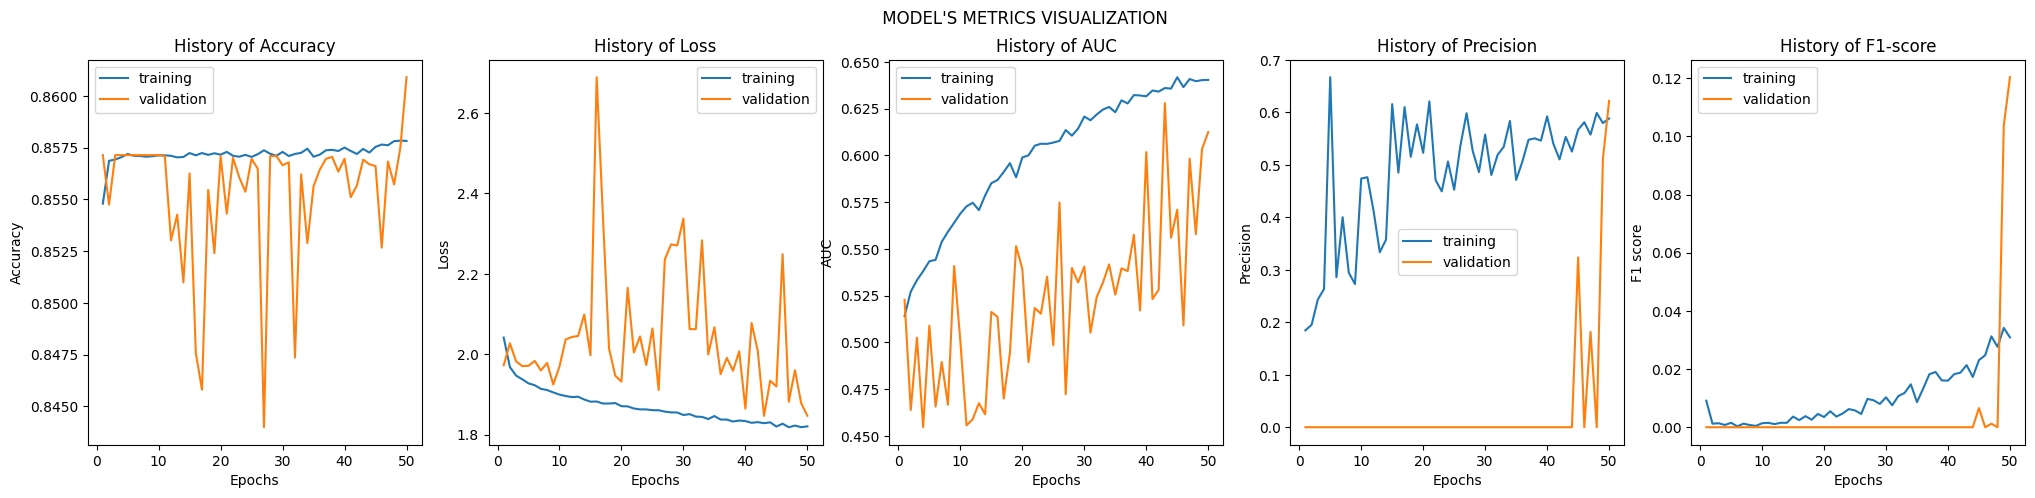

In [41]:
#%% PLOTTING RESULTS (Train vs Validation FOLDER 1)

def Train_Val_Plot(acc,val_acc,loss,val_loss,auc,val_auc,precision,val_precision,f1,val_f1):
    
    fig, (ax1, ax2,ax3,ax4,ax5) = plt.subplots(1,5, figsize= (25,5))
    fig.suptitle(" MODEL'S METRICS VISUALIZATION ")

    ax1.plot(range(1, len(acc) + 1), acc)
    ax1.plot(range(1, len(val_acc) + 1), val_acc)
    ax1.set_title('History of Accuracy')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Accuracy')
    ax1.legend(['training', 'validation'])


    ax2.plot(range(1, len(loss) + 1), loss)
    ax2.plot(range(1, len(val_loss) + 1), val_loss)
    ax2.set_title('History of Loss')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Loss')
    ax2.legend(['training', 'validation'])
    
    ax3.plot(range(1, len(auc) + 1), auc)
    ax3.plot(range(1, len(val_auc) + 1), val_auc)
    ax3.set_title('History of AUC')
    ax3.set_xlabel('Epochs')
    ax3.set_ylabel('AUC')
    ax3.legend(['training', 'validation'])
    
    ax4.plot(range(1, len(precision) + 1), precision)
    ax4.plot(range(1, len(val_precision) + 1), val_precision)
    ax4.set_title('History of Precision')
    ax4.set_xlabel('Epochs')
    ax4.set_ylabel('Precision')
    ax4.legend(['training', 'validation'])
    
    ax5.plot(range(1, len(f1) + 1), f1)
    ax5.plot(range(1, len(val_f1) + 1), val_f1)
    ax5.set_title('History of F1-score')
    ax5.set_xlabel('Epochs')
    ax5.set_ylabel('F1 score')
    ax5.legend(['training', 'validation'])


    plt.show()
    

Train_Val_Plot(history.history['accuracy'],history.history['val_accuracy'],
               history.history['loss'],history.history['val_loss'],
               history.history['auc'],history.history['val_auc'],
               history.history['precision'],history.history['val_precision'],
               history.history['f1_score'],history.history['val_f1_score']
              )

2/2 [==============================] - 2s 162ms/step
Accuracy =  0.25


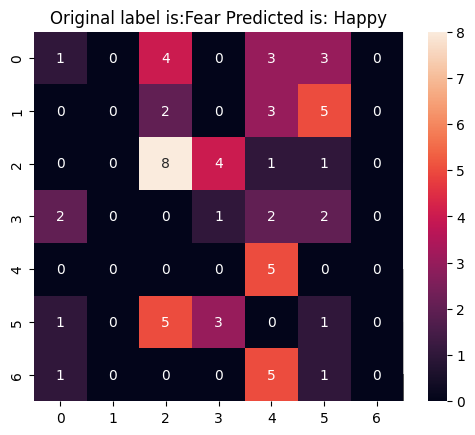

              precision    recall  f1-score   support

       angry       0.20      0.09      0.12        11
     disgust       0.00      0.00      0.00        10
        fear       0.42      0.57      0.48        14
       happy       0.12      0.14      0.13         7
     neutral       0.26      1.00      0.42         5
         sad       0.08      0.10      0.09        10
    surprise       0.00      0.00      0.00         7

    accuracy                           0.25        64
   macro avg       0.16      0.27      0.18        64
weighted avg       0.17      0.25      0.19        64



c:\Python10\lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python10\lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python10\lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [13]:
from sklearn.metrics import confusion_matrix, classification_report
from keras.models import load_model
import random
#Test the model
my_model = load_model('model.h5', compile=False)

#Generate a batch of images
test_img, test_lbl = valid_dataset.__next__()
predictions=my_model.predict(test_img)

predictions = np.argmax(predictions, axis=1)
test_labels = np.argmax(test_lbl, axis=1)

from sklearn import metrics
print ("Accuracy = ", metrics.accuracy_score(test_labels, predictions))

#Confusion Matrix - verify accuracy of each class
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_labels, predictions)
#print(cm)
import seaborn as sns
sns.heatmap(cm, annot=True)

class_labels=['Angry','Disgust', 'Fear', 'Happy','Neutral','Sad','Surprise']
#Check results on a few select images
n=random.randint(0, test_img.shape[0] - 1)
image = test_img[n]
orig_labl = class_labels[test_labels[n]]
pred_labl = class_labels[predictions[n]]
plt.imshow(image[:,:,0], cmap='gray')
plt.title("Original label is:"+orig_labl+" Predicted is: "+ pred_labl)
plt.show()


class_names = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad','surprise']  # Replace with your actual class names
report = classification_report(test_labels, predictions, target_names=class_names, labels=range(len(class_names)))
print(report)